## Homework 1 - Phase I & II Analysis Using Shewhart $\bar{X}$ and R/s Charts
### Dr. Austin Brown
### Kennesaw State University

**DUE: September 19, 2026 via D2L**

## Instructions:

A company called Blue Ridge Filament Co (BRFC) manufactures 1.75 mm PLA filament for 3D printers, selling to both hobbyist and small-manufacturing customers. Over the last quarter, customer support tickets describing clogging, stringing, and inconsistent print layers have risen sharply, and BRFC recently lost a wholesale account to a competitor over “inconsistent quality.” The plant manager has asked your quality control team to investigate Extruder Line 3, the line most frequently named in the complaint data, and to determine whether the line is running in a state of statistical control. This line is about six months away from needing its heating element replaced, but it could be replaced sooner if necessary.

The plant manager is particularly interested in the filament diameter produced (mm), measured inline by a laser micrometer as each spool is produced. Diameter that runs too thin causes under-extrusion and stringing; diameter that runs too thick causes jams and clogs in customers' print heads. Filament diameter is treated as a continuous, normally-distributed quality characteristic for this assignment.

Your team pulls a baseline (Phase I) sample of production data from Line 3: 5 spools sampled at random each week, for 25 consecutive weeks. After validating statistical control and process capability, the team can establish an ongoing monitoring plan for Phase II analysis.

## Key Specifications

| Quantity | Value |
|---|---|
| Target diameter | 1.750 mm |
| Lower Specification Limit (LSL) | 1.700 mm |
| Upper Specification Limit (USL) | 1.800 mm |
| Subgroup size (n) | 5 spools per week |
| Phase I subgroups (m) | 25 weeks |
| Phase II subgroups | 20 weeks |

In [18]:
## Setup ##

## Specify your GitHub username ##
user_name <- "naomketer"

## Specify the repository ##
repo_name <- "STAT-7110-Quality-Control"

## Set the web address to your forked repository ##
repo_address <- paste0(
  "https://github.com/",
  user_name,
  "/",
  repo_name,
  ".git"
)

## Clone repo if it is not already cloned ##
if (!dir.exists(repo_name)) {
  system(paste("git clone", repo_address))
} else {
  print("Repository already cloned to Colab.")
}

## Set working directory to HW1 ##
setwd("STAT-7110-Quality-Control/Assignments/HW1")

## Load libraries ##
library(tidyverse)
library(readxl)
library(qcc)

## Define & Measure

### Q1: Briefly describe the purpose of this analysis

The purpose of this analysis is to determine whether Extruder Line 3 is operating in a state of statistical control with respect to filament diameter and whether the process is capable of meeting the specification limits of 1.700 mm to 1.800 mm. Phase I data will be used to identify any assignable causes of variation and establish stable control limits. These limits will then be used to monitor future production in Phase II. The results will also help determine whether corrective action or maintenance of Line 3 should be considered.

### Q2: Identify the quality characteristic your team will monitor, classify its units and measurement scale.

The quality characteristic being monitored is filament diameter produced by Extruder Line 3. Diameter is measured in millimeters (mm) using an inline laser micrometer. It is a continuous quantitative variable measured on a ratio scale, because the values are numeric, differences between measurements are meaningful, and zero represents the absence of diameter.

### Q3: Briefly describe why a Shewhart $\bar{X}$ and $R/s$ chart would be appropriate in this scenario. What are its limitations?

A Shewhart \(\bar{X}\) and \(R/s\) chart is appropriate because filament diameter is a continuous measurement collected in weekly subgroups of five spools. The \(\bar{X}\) chart monitors the process mean, while the \(R\) or \(s\) chart monitors process variability. Using both charts together helps determine whether the process is stable over time.

One limitation is that Shewhart charts are better at detecting moderate or large shifts than very small or gradual changes. They can also give occasional false alarms, and the R chart is more sensitive to departures from normality. In addition, the charts can show that a process may be out of control, but they do not identify the exact cause of the problem.

## Analyze

### Q4: Read the Phase I data into R. Calculate and report the estimated process mean and standard deviation using both the $R$ and $s$ methods.




In [6]:
install.packages(c("tidyverse", "readxl", "qcc"))

library(tidyverse)
library(readxl)
library(qcc)

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.1     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.3     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Package 'qcc' version 2.7

Type 'citation("qcc")' for citing this R package in publications.



In [23]:
## Q4 Code ##

## Read in the Phase I Filament Diameter Data ##
phase1_df <- read_excel("FilamentDiameter_PhaseI.xlsx")

## Data Integrity Check ##
phase1_df |>
  glimpse()

## These data are organized in wide format,
## where each row represents one subgroup (week)
## with five filament diameter measurements. ##

## Keep only the filament diameter measurements ##
phase1_data <- phase1_df |>
  select(-Subgroup)

## Estimate process mean and standard deviation using R method ##
phase1_R <- qcc(
  phase1_data,
  type = "xbar",
  std.dev = "UWAVE-R",
  plot = FALSE
)

## Estimate process mean and standard deviation using s method ##
phase1_s <- qcc(
  phase1_data,
  type = "xbar",
  std.dev = "UWAVE-SD",
  plot = FALSE
)

## Report Phase I estimates ##
phase1_R$center
phase1_R$std.dev

phase1_s$center
phase1_s$std.dev

Rows: 25
Columns: 6
$ Subgroup <dbl> 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18…
$ Meas1    <dbl> 1.759712, 1.752064, 1.755094, 1.763434, 1.751915, 1.746336, 1…
$ Meas2    <dbl> 1.742690, 1.733264, 1.745186, 1.746130, 1.757228, 1.769405, 1…
$ Meas3    <dbl> 1.771452, 1.767347, 1.753372, 1.747787, 1.745419, 1.752795, 1…
$ Meas4    <dbl> 1.758564, 1.761277, 1.763998, 1.747608, 1.755608, 1.750858, 1…
$ Meas5    <dbl> 1.755669, 1.744550, 1.745075, 1.748262, 1.742620, 1.737254, 1…


[1] 1.754017

[1] 0.01144864

[1] 1.754017

[1] 0.01154485

The estimated Phase I process mean was 1.7540 mm. The estimated process standard deviation was 0.01145 mm using the R method and 0.01154 mm using the s method. The two methods give very similar estimates of process variability.


### Q5: Construct a Phase I $R$ chart. Does the chart show evidence of statistical control? If not, identify the out-of-control subgroup(s) by number and provide a contextual explanation as to why these OOC points may have been observed, omit these points, and replot the chart until statistical control is observed.

[1] 0.02662954

,LCL,UCL
,0,0.05630735


$beyond.limits
[1] 19

$violating.runs
numeric(0)

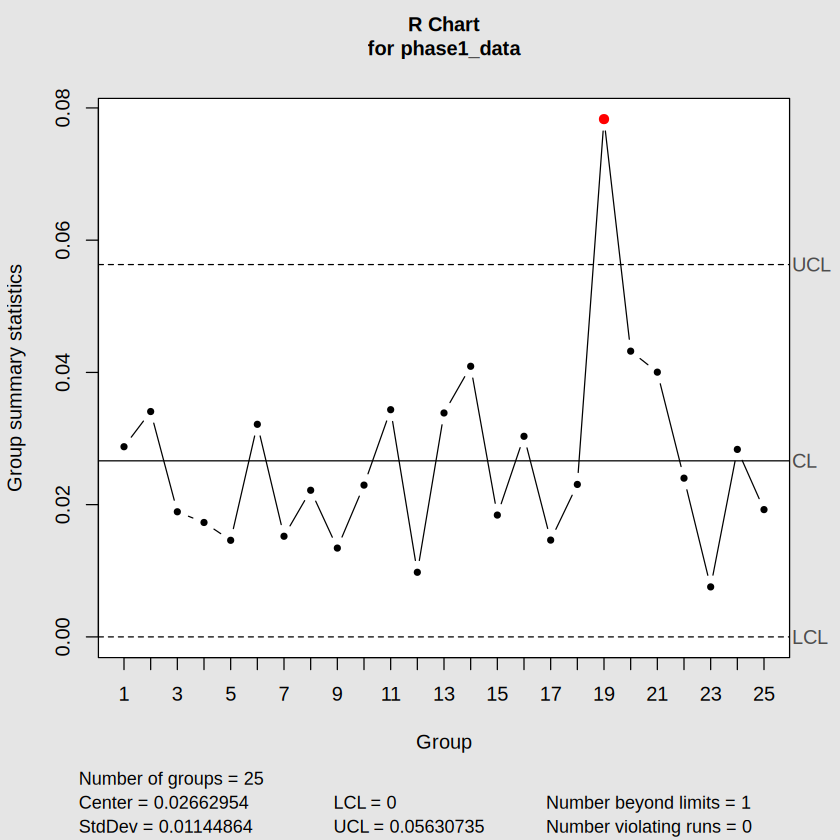

In [24]:

## Q5: Initial Phase I R Chart ##

phase1_Rchart <- qcc(
  phase1_data,
  type = "R",
  plot = TRUE
)

## Report chart parameters and violations ##
phase1_Rchart$center
phase1_Rchart$limits
phase1_Rchart$violations

The initial R chart shows that subgroup 19 is above the upper control limit, indicating unusually high process variability during that subgroup. This suggests that an assignable cause may have affected the process during that week.

[1] 0.0244762

,LCL,UCL
,0,0.05175418


$beyond.limits
integer(0)

$violating.runs
numeric(0)

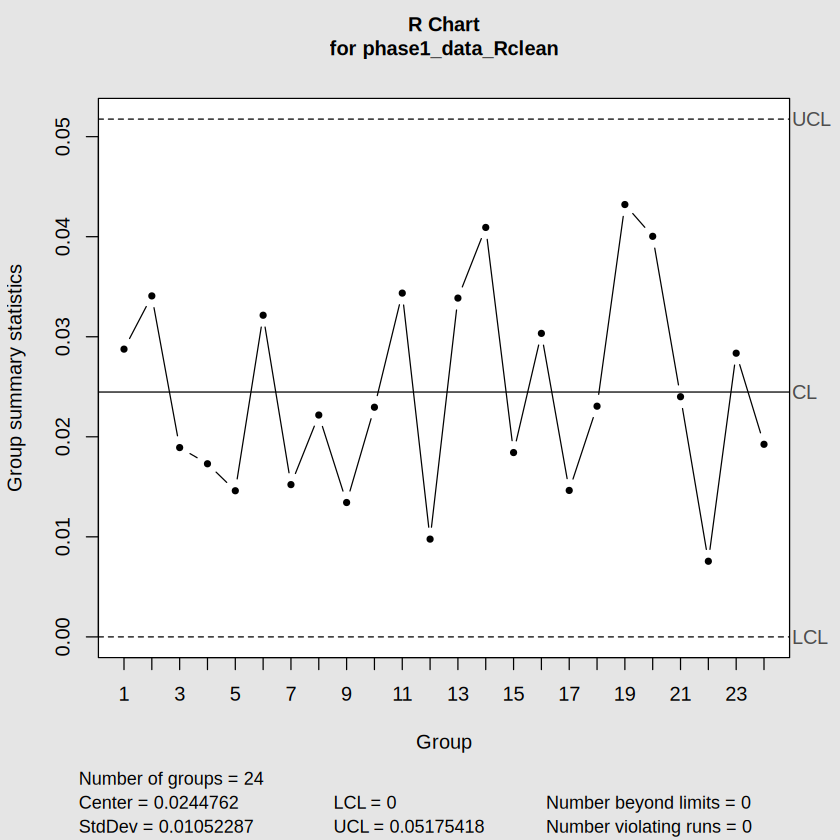

In [25]:
## Remove the OOC subgroup and replot the R chart ##

phase1_data_Rclean <- phase1_df |>
  filter(Subgroup != 19) |>
  select(-Subgroup)

phase1_Rchart_clean <- qcc(
  phase1_data_Rclean,
  type = "R",
  plot = TRUE
)

## Report revised chart parameters and violations ##
phase1_Rchart_clean$center
phase1_Rchart_clean$limits
phase1_Rchart_clean$violations

Interpretation of Revised R Chart

After removing subgroup 19 and recalculating the control limits, all remaining subgroups fall within the control limits and there are no violating runs. Therefore, the remaining Phase I process variability is in statistical control.

Q5 Final Conclusion

The initial R chart identified subgroup 19 as out of control because its range was above the upper control limit. This indicates unusually high process variability during that week. A possible explanation could be temporary temperature instability, equipment adjustment, or material variation. After removing subgroup 19 and recalculating the chart, all remaining subgroups were within the control limits with no violating runs. Therefore, the remaining Phase I process variability was considered statistically in control.



### Q6: Using only the subgroups retained after Q5, construct the Phase I $\bar{X}$ chart. Does the chart show evidence of statistical control? If not, identify the out-of-control subgroup(s) by number and provide a contextual explanation as to why these OOC points may have been observed, omit these points, and replot the chart until statistical control is observed.

[1] 1.753618

,LCL,UCL
,1.7395,1.767736


$beyond.limits
[1] 12

$violating.runs
[1] 23 24

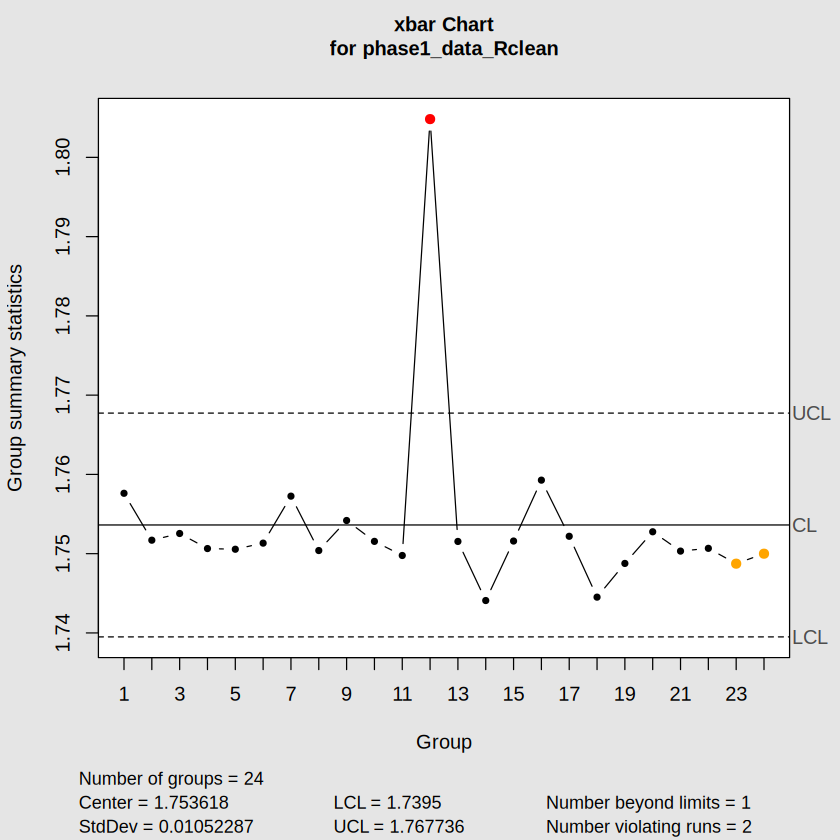

In [26]:
## Q6: Initial Phase I X-bar Chart ##

phase1_xbar_R <- qcc(
  phase1_data_Rclean,
  type = "xbar",
  std.dev = "UWAVE-R",
  plot = TRUE
)

## Report chart parameters and violations ##
phase1_xbar_R$center
phase1_xbar_R$limits
phase1_xbar_R$violations

Interpretation of Initial \(\bar X\) Chart

The initial \(\bar{X}\) chart is not in statistical control. Subgroup 12 is above the upper control limit, indicating that the average filament diameter during that week was unusually high compared with the remaining Phase I process. A possible explanation could be a temporary change in process settings, temperature conditions, or material characteristics. The chart also flags a run-rule pattern near the end of the Phase I data.

[1] 1.751392

,LCL,UCL
,1.736905,1.765879


$beyond.limits
integer(0)

$violating.runs
numeric(0)

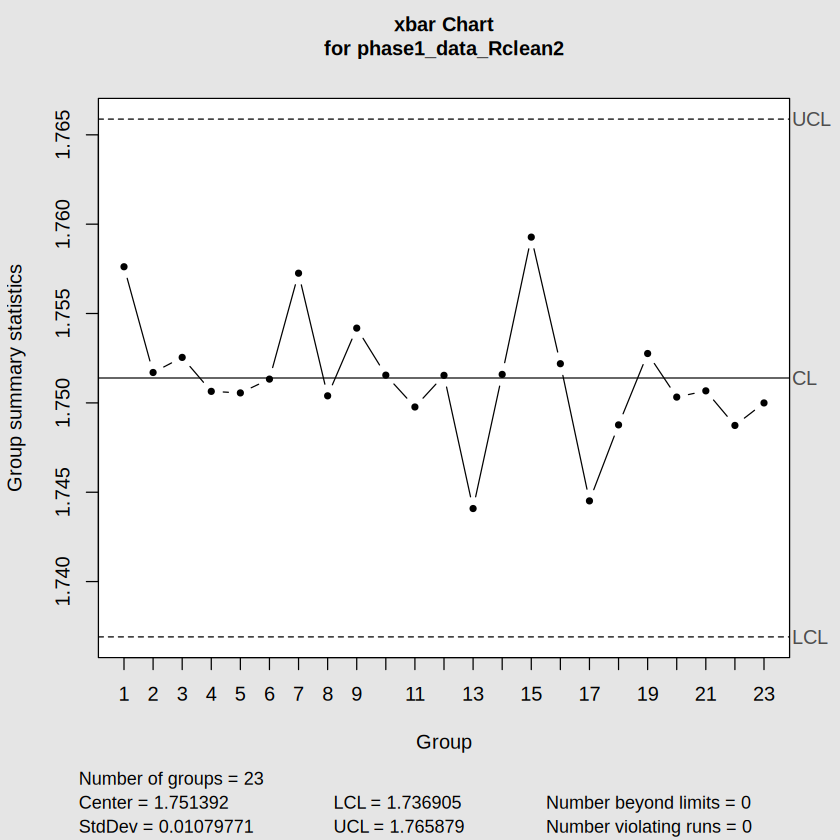

In [27]:
## Remove the OOC subgroup and replot the X-bar chart ##

phase1_data_Rclean2 <- phase1_df |>
  filter(!Subgroup %in% c(12, 19)) |>
  select(-Subgroup)

phase1_xbar_R2 <- qcc(
  phase1_data_Rclean2,
  type = "xbar",
  std.dev = "UWAVE-R",
  plot = TRUE
)

## Report revised chart parameters and violations ##
phase1_xbar_R2$center
phase1_xbar_R2$limits
phase1_xbar_R2$violations

Interpretation of Revised \(\bar X\) Chart

After removing subgroup 12 and recalculating the control limits, all remaining subgroup means fall within the control limits and there are no violating runs. Therefore, the remaining Phase I process mean is in statistical control.

Q6 Final Conclusion

The initial \(\bar X\) chart was not in statistical control because subgroup 12 was above the upper control limit. This indicates that the average filament diameter during that week was unusually high. A possible explanation could be a temporary change in process settings, temperature conditions, or material characteristics. After removing subgroup 12 and recalculating the chart, all remaining subgroup means were within the control limits with no violating runs. Therefore, the remaining Phase I process mean was considered statistically in control.

### Q7: Repeat the same process in Q4 - Q6 now using the $s$ chart instead of the $R$ chart

In [28]:
## Q7: Estimate process standard deviation using s method ##

sig_hat_s <- sd.xbar(phase1_data)

sig_hat_s

[1] 0.01144864

[1] 0.01085199

,LCL,UCL
,0,0.02266979


$beyond.limits
[1] 19

$violating.runs
numeric(0)

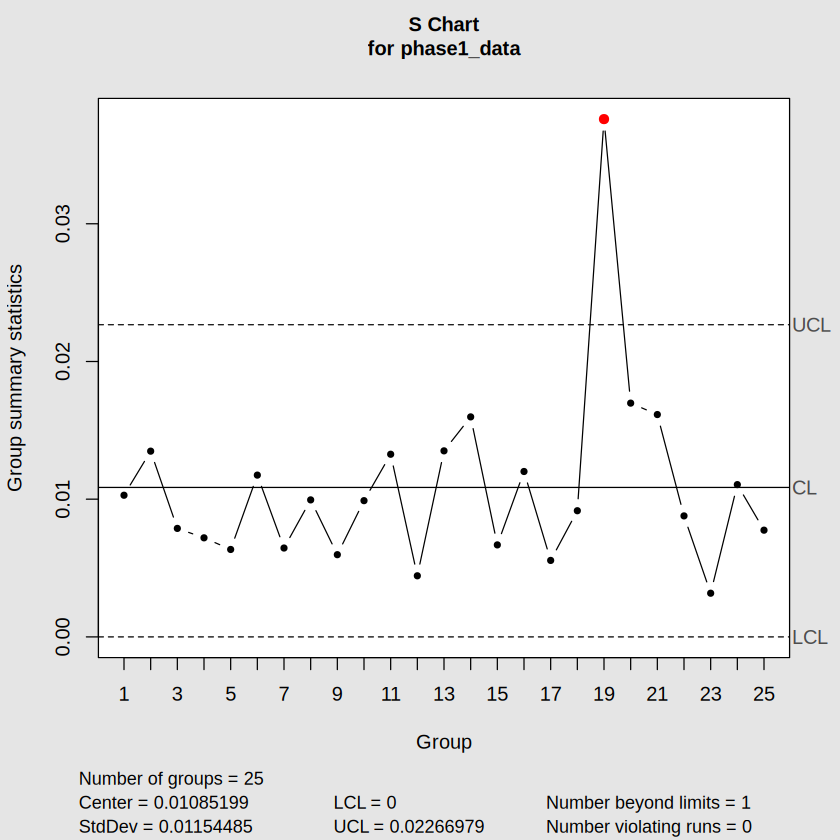

In [29]:
## Initial Phase I s Chart ##

phase1_schart <- qcc(
  phase1_data,
  type = "S",
  plot = TRUE
)

phase1_schart$center
phase1_schart$limits
phase1_schart$violations

Interpretation:

The initial s chart is not in statistical control because subgroup 19 is above the upper control limit, indicating unusually high process variability during that week. A possible explanation could be temporary temperature instability, equipment adjustment, or material variation.

[1] 0.009737409

,LCL,UCL
,0,0.02034143


$beyond.limits
integer(0)

$violating.runs
numeric(0)

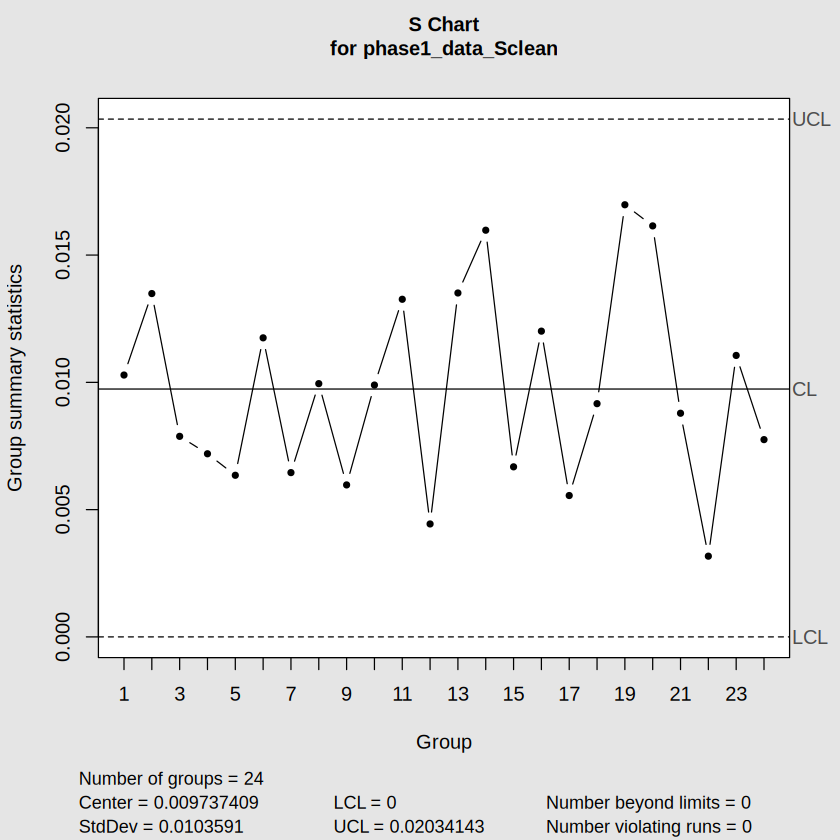

In [30]:
## Remove subgroup 19 ##

phase1_data_Sclean <- phase1_df |>
  filter(Subgroup != 19) |>
  select(-Subgroup)

phase1_schart_clean <- qcc(
  phase1_data_Sclean,
  type = "S",
  plot = TRUE
)

phase1_schart_clean$center
phase1_schart_clean$limits
phase1_schart_clean$violations

[1] 1.753618

,LCL,UCL
,1.73972,1.767517


$beyond.limits
[1] 12

$violating.runs
[1] 23 24

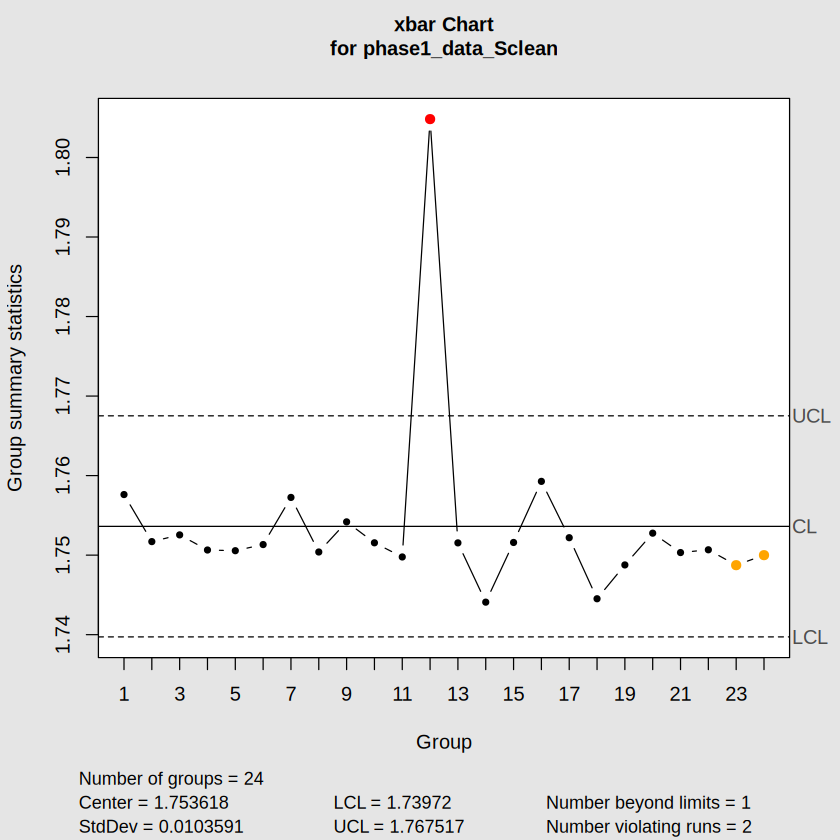

In [13]:
## Construct Phase I X-bar Chart using subgroups retained after s-chart analysis ##
phase1_xbar_s <- qcc(
  phase1_data_Sclean,
  type = "xbar",
  std.dev = "UWAVE-SD",
  plot = TRUE
)

phase1_xbar_s$center
phase1_xbar_s$limits
phase1_xbar_s$violations

The initial s chart identified subgroup 19 as out of control due to unusually high within-subgroup variability. After removing subgroup 19 and recalculating the chart, all remaining subgroups were within the control limits and there were no violating runs. Therefore, process variability was considered statistically in control using the s method.


In [31]:
## Updated s-method estimate of process standard deviation ##

sig_hat_s_clean <- sd.xbar(phase1_data_Sclean)

sig_hat_s_clean

[1] 0.01052287

[1] 1.753618

,LCL,UCL
,1.7395,1.767736


$beyond.limits
[1] 12

$violating.runs
[1] 23 24

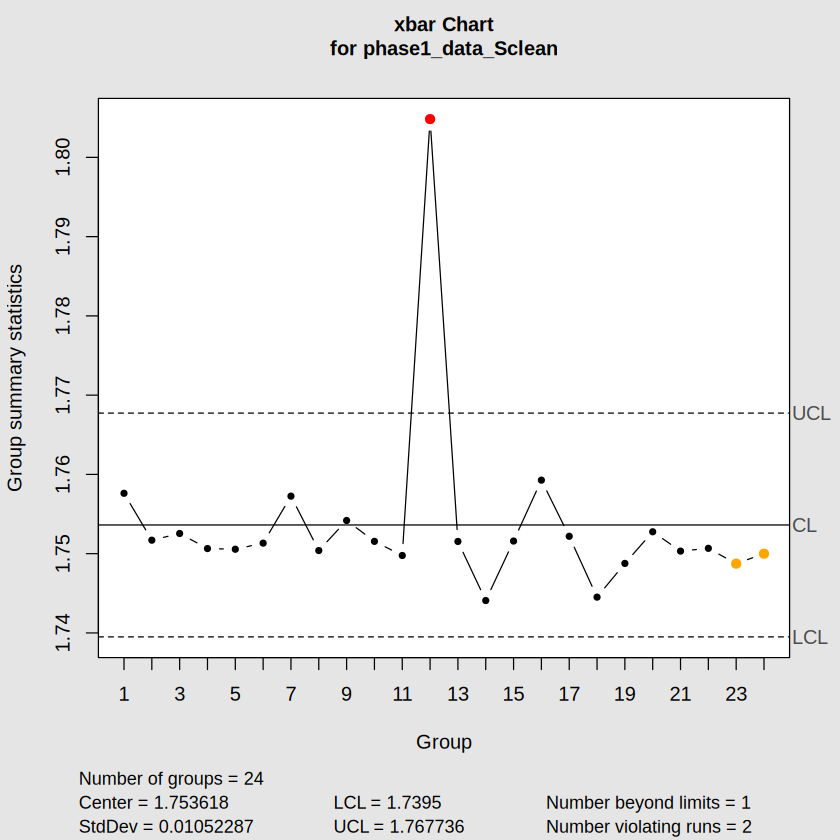

In [32]:
## Phase I X-bar Chart using s-method estimate ##

phase1_xbar_s <- qcc(
  phase1_data_Sclean,
  type = "xbar",
  std.dev = sig_hat_s_clean,
  plot = TRUE
)

phase1_xbar_s$center
phase1_xbar_s$limits
phase1_xbar_s$violations

Interpretation of Initial \(\bar X\) Chart Using the s Method

The \(\bar X\) chart is not in statistical control because subgroup 12 is above the upper control limit, indicating an unusually high average filament diameter during that week. A possible explanation could be a temporary change in process settings, temperature conditions, or material characteristics. The chart also shows a run-rule signal near the end of the Phase I data.

In [34]:
## Remove subgroups 12 and 19 ##

phase1_data_Sclean2 <- phase1_df |>
  filter(!Subgroup %in% c(12, 19)) |>
  select(-Subgroup)

In [35]:
## Final s-method estimate of process standard deviation ##

sig_hat_s_final <- sd.xbar(phase1_data_Sclean2)

sig_hat_s_final

[1] 0.01079771

[1] 1.751392

,LCL,UCL
,1.736905,1.765879


$beyond.limits
integer(0)

$violating.runs
numeric(0)

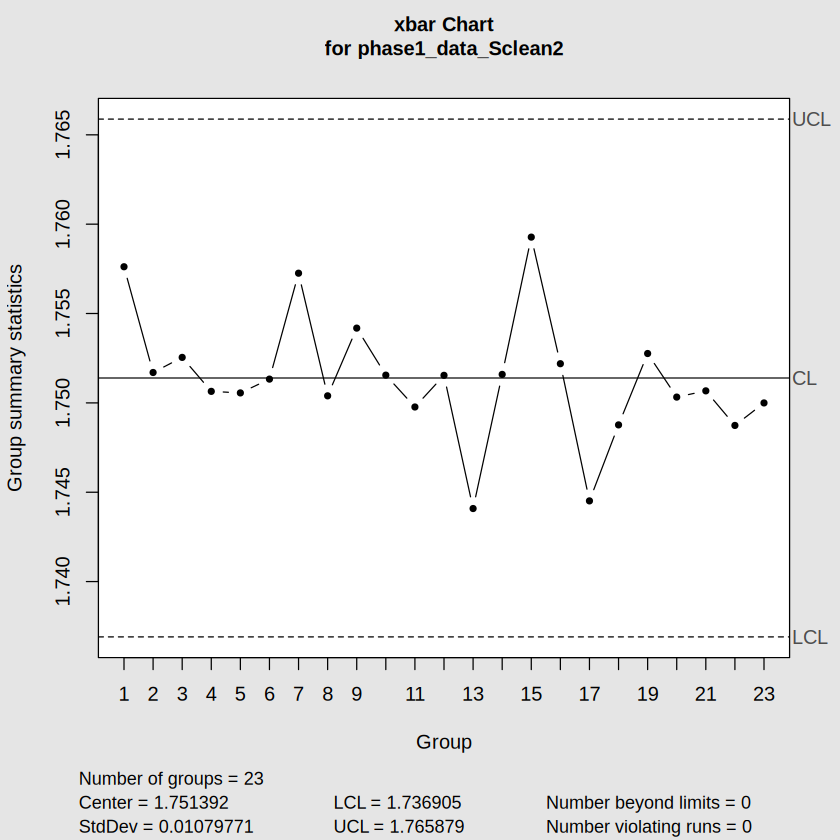

In [36]:
## Revised Phase I X-bar Chart using s-method estimate ##

phase1_xbar_s2 <- qcc(
  phase1_data_Sclean2,
  type = "xbar",
  std.dev = sig_hat_s_final,
  plot = TRUE
)

phase1_xbar_s2$center
phase1_xbar_s2$limits
phase1_xbar_s2$violations

Interpretation of Revised \(\bar X\) Chart

After removing subgroup 12 and recalculating the control limits, all remaining subgroup means fall within the control limits and there are no violating runs. Therefore, the remaining Phase I process mean is in statistical control using the s method.

[1] 0.009967871

,LCL,UCL
,0,0.02082286


$beyond.limits
integer(0)

$violating.runs
numeric(0)

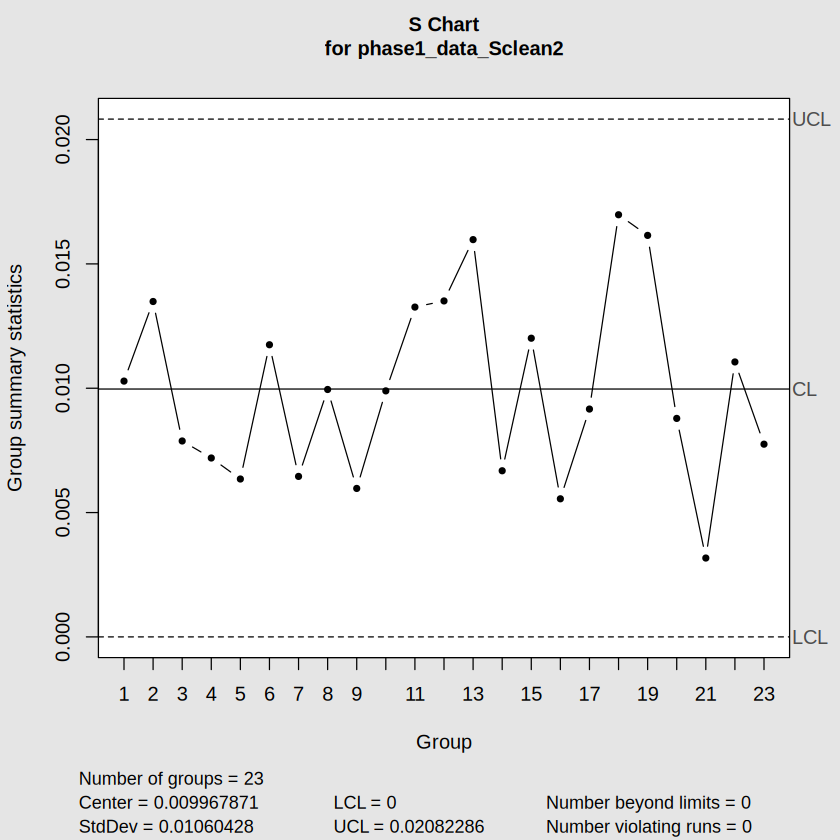

In [37]:
## Final Phase I s Chart ##

phase1_schart_final <- qcc(
  phase1_data_Sclean2,
  type = "S",
  plot = TRUE
)

phase1_schart_final$center
phase1_schart_final$limits
phase1_schart_final$violations

Interpretation of Final s Chart

Using the final 23 retained Phase I subgroups, all subgroup standard deviations fall within the control limits and there are no violating runs. Therefore, the remaining Phase I process variability is in statistical control using the s chart.

Q7 Final Conclusion

Using the s-chart method, subgroup 19 was first identified as out of control because of unusually high process variability. After removing subgroup 19, the \(\bar X\) chart identified subgroup 12 as out of control because its average filament diameter was above the upper control limit. After removing both subgroups 19 and 12 and recalculating the charts, all remaining subgroup means and standard deviations were within the control limits with no violating runs. Therefore, the final Phase I process was considered statistically in control using the s method.

### Q8: Using your final Phase I estimates of the process mean and process standard deviation (using $s$ method), perform a process capability analysis against the specification limits given about. Report and interpret $FNC$, $C_p$, $C_{pk}$, and $C_{pm}$. Is the process capable of meeting specification? Is it well-centered?

In [38]:
## Q8: Fraction Nonconforming ##

FNC <- pnorm(
  1.700,
  mean = phase1_xbar_s2$center,
  sd = sig_hat_s_final
) +
pnorm(
  1.800,
  mean = phase1_xbar_s2$center,
  sd = sig_hat_s_final,
  lower.tail = FALSE
)

FNC

[1] 4.341006e-06


Process Capability Analysis

Call:
process.capability(object = phase1_xbar_s2, spec.limits = c(1.7,     1.8), target = 1.75, std.dev = sig_hat_s_final, nsigmas = 3)

Number of obs = 115          Target = 1.75
       Center = 1.751           LSL = 1.7
       StdDev = 0.0108          USL = 1.8

Capability indices:

      Value   2.5%  97.5%
Cp    1.544  1.343  1.743
Cp_l  1.587  1.406  1.767
Cp_u  1.501  1.329  1.672
Cp_k  1.501  1.296  1.705
Cpm   1.531  1.332  1.730

Exp<LSL 0%	 Obs<LSL 0%
Exp>USL 0%	 Obs>USL 0%


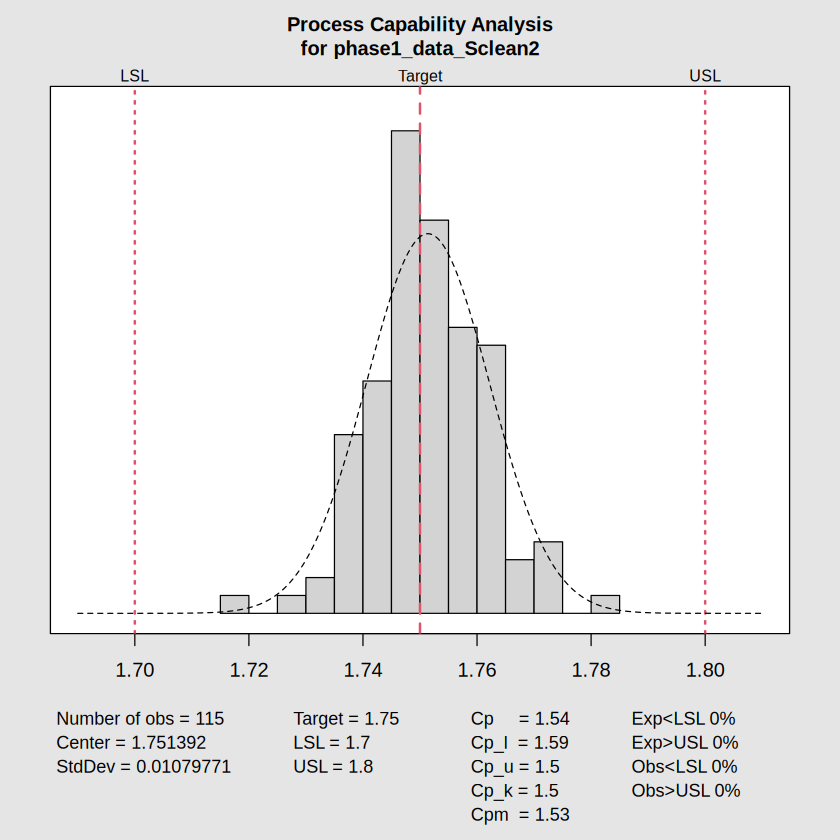

In [39]:
## Q8: Process Capability Analysis ##

process.capability(
  phase1_xbar_s2,
  spec.limits = c(1.700, 1.800),
  target = 1.750,
  std.dev = sig_hat_s_final,
  nsigmas = 3
)

The FNC is \(4.341 \times 10^{-6}\), so very little output is expected to fall outside the specification limits. The process is capable because \(C_p = 1.544\), \(C_{pk} = 1.501\), and \(C_{pm} = 1.531\), which are all greater than 1. Since \(C_{pk}\) and \(C_{pm}\) are close to \(C_p\), the process is also reasonably well-centered near the target of 1.750 mm.


## Improve

### Q9: Briefly provide a contextual explanation as to leaving OOC points in the Phase I calculation of the control limits after identifying an assignable cause is not advisable.

Leaving an out-of-control point with an assignable cause in the Phase I data can distort the estimated process mean, variation, and control limits. This can make the limits less representative of the normal process and make future shifts harder to detect. Removing those points helps the Phase I limits better represent the stable process.

## Control

### Q10: Read in the Phase II data into R. Using the finalized Phase I center line and control limits from Q7, construct the Phase II $\bar{X}$ chart. Do any subgroups plot outside the control limits?

In [40]:
## Q10: Read in Phase II data ##

phase2_df <- read_excel("FilamentDiameter_PhaseII.xlsx")

phase2_df |>
  glimpse()

phase2_data <- phase2_df |>
  select(-Subgroup)

Rows: 20
Columns: 6
$ Subgroup <dbl> 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18…
$ Meas1    <dbl> 1.741281, 1.752716, 1.757787, 1.750684, 1.750781, 1.746839, 1…
$ Meas2    <dbl> 1.755570, 1.752597, 1.749910, 1.739595, 1.750607, 1.758723, 1…
$ Meas3    <dbl> 1.754157, 1.748972, 1.755079, 1.747991, 1.750896, 1.751448, 1…
$ Meas4    <dbl> 1.754749, 1.749849, 1.747444, 1.749558, 1.754583, 1.752087, 1…
$ Meas5    <dbl> 1.733665, 1.745653, 1.756482, 1.756971, 1.750307, 1.744185, 1…


In [41]:
## Save final Phase I X-bar center and limits ##

xbar_center <- phase1_xbar_s2$center
xbar_lims <- phase1_xbar_s2$limits

$beyond.limits
integer(0)

$violating.runs
[1] 14 15 16 17 18 19 20

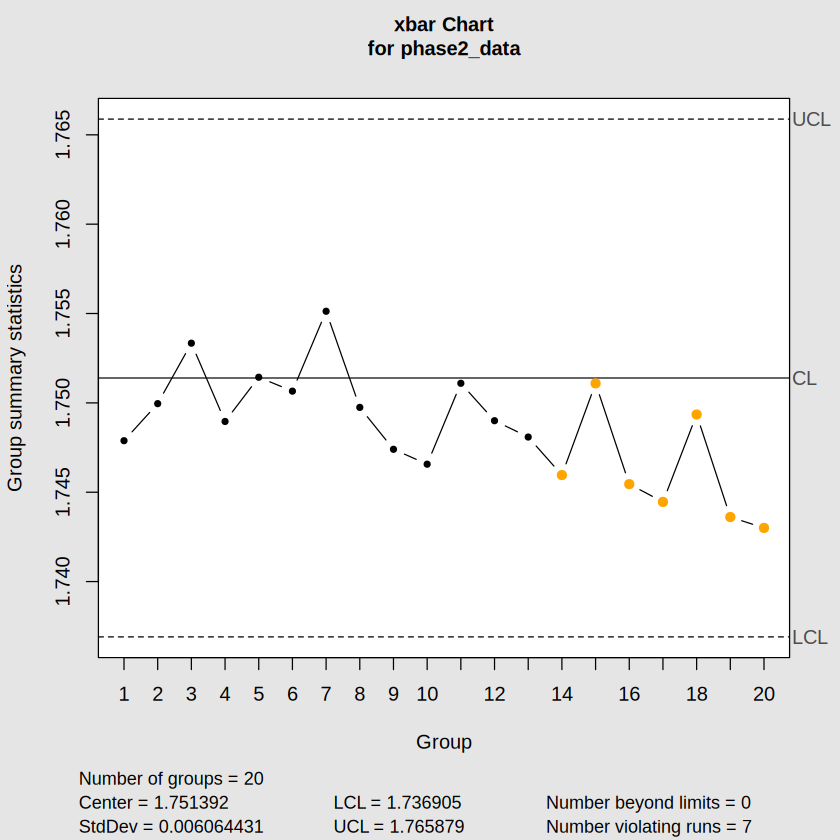

In [42]:
## Phase II X-bar Chart ##

phase2_xbar <- qcc(
  phase2_data,
  type = "xbar",
  center = xbar_center,
  limits = xbar_lims,
  plot = TRUE
)

phase2_xbar$violations

Interpretation

No Phase II subgroup means fall outside the control limits. However, subgroups 14–20 form a violating run below the center line, which suggests that the process mean may have shifted downward even though no individual subgroup is outside the control limits.

### Q11: Construct a Phase II $s$ chart. Do any subgroups plot outside the control limits?

In [43]:
## Q11: Save final Phase I s-chart center and limits ##

s_center <- phase1_schart_final$center
s_lims <- phase1_schart_final$limits

$beyond.limits
integer(0)

$violating.runs
 [1]  7  8  9 10 11 12 13 14 15 16 17 18 19 20

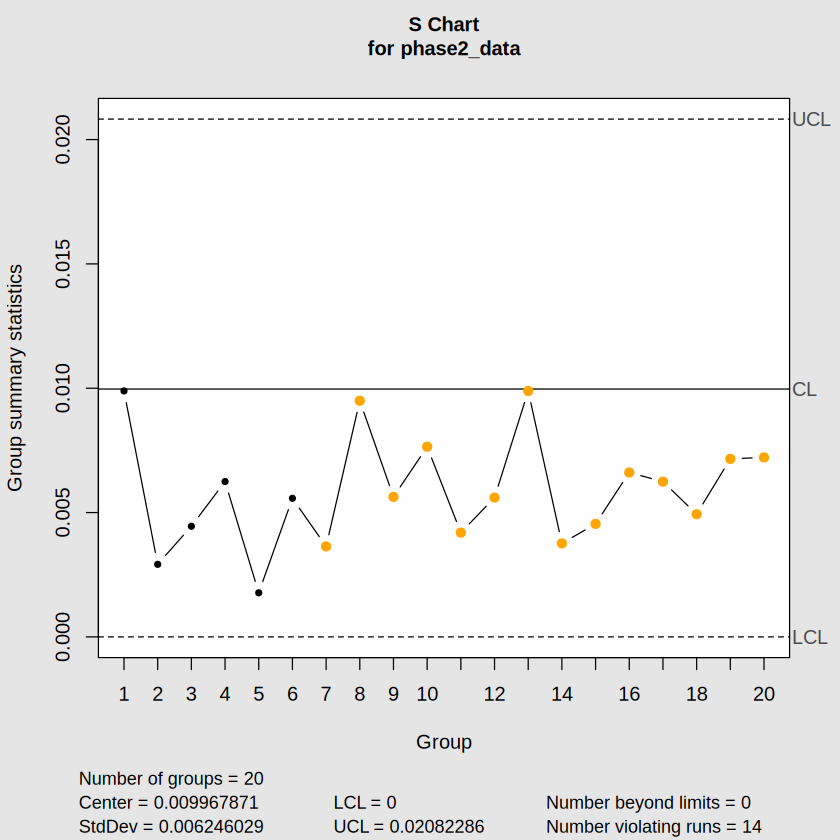

In [44]:
## Phase II s Chart ##

phase2_s <- qcc(
  phase2_data,
  type = "S",
  center = s_center,
  limits = s_lims,
  plot = TRUE
)

phase2_s$violations

Interpretation

No Phase II subgroup standard deviations fall outside the control limits. However, subgroups 7–20 form a violating run, indicating a non-random pattern in process variability even though no individual subgroup is outside the limits.

Final Conclusion

The Phase II \(s\) chart has no points beyond the control limits, but the run-rule signal suggests that the process variability may have changed and should continue to be monitored.

### Q12: Provide an overview of the results that the plant manager can provide the Vice President of Operations. Do they need to completely overhaul line 3 or is it salvagable?

Phase I showed that Line 3 can operate in statistical control and is capable of meeting the filament diameter specifications. The capability indices were all above 1, and the process was reasonably well-centered near the 1.750 mm target.

In Phase II, no subgroup fell outside the control limits, but both the \(\bar X\) and \(s\) charts showed run-rule patterns. This suggests that the process may be starting to shift and should be investigated.

Based on these results, Line 3 does not appear to require a complete overhaul. The process appears salvageable, but the plant should investigate possible causes of the recent shift and inspect the heating element and other process settings. Since the heating element is already approaching its scheduled replacement, earlier maintenance or replacement may be reasonable if it is found to be contributing to the change..

